# GEO Satellite Orbital Behavior Analysis
Gabriel Casarotto

Date: 11/03/2026

### Data analysis:
In this notebook, we perform an exploratory analysis of a dataset containing
the TLE history of several GEO satellites since 2020.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from sgp4.api import Satrec

df = pd.read_csv(r'mon_dataset_geo.csv')

In [2]:
# convert the 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'])

# removal of microseconds for a more readable display
df['date'] = df['date'].dt.floor('s')

df.head()

,norad_id,date,line1,line2
0,25546,2020-01-01 18:32:50,1 25546U 98068A 20001.77281198 -.00000071 +0...,2 25546 006.0044 062.8088 0006548 287.4973 127...
1,25546,2020-01-02 02:41:42,1 25546U 98068A 20002.11229626 -.00000060 0...,2 25546 6.0051 62.8073 0006553 287.5980 248...
2,25546,2020-01-02 16:13:02,1 25546U 98068A 20002.67571962 -.00000042 +0...,2 25546 006.0062 062.8048 0006578 287.8198 089...
3,25546,2020-01-03 16:18:59,1 25546U 98068A 20003.67985098 -.00000012 +0...,2 25546 006.0081 062.8002 0006602 288.1736 086...
4,25546,2020-01-04 16:59:56,1 25546U 98068A 20004.70829160 .00000016 0...,2 25546 6.0101 62.7956 0006627 288.5308 93...


I look at the general information in my dataframe.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123234 entries, 0 to 123233
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   norad_id  123234 non-null  int64         
 1   date      123234 non-null  datetime64[ns]
 2   line1     123234 non-null  object        
 3   line2     123234 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 3.8+ MB


Now that I've read the most important information, I can start going into detail.

In [4]:
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"Number of unique satellites: {len(df['norad_id'].unique())}")

# sort data by satellite then by date
df = df.sort_values(['norad_id', 'date'])
print(f"Period covered: {df['date'].min().date()} -> {df['date'].max().date()}")

display(df.head())

The dataset contains 123234 rows and 4 columns.
Number of unique satellites: 25
Period covered: 2020-01-01 -> 2026-03-10


,norad_id,date,line1,line2
0,25546,2020-01-01 18:32:50,1 25546U 98068A 20001.77281198 -.00000071 +0...,2 25546 006.0044 062.8088 0006548 287.4973 127...
1,25546,2020-01-02 02:41:42,1 25546U 98068A 20002.11229626 -.00000060 0...,2 25546 6.0051 62.8073 0006553 287.5980 248...
2,25546,2020-01-02 16:13:02,1 25546U 98068A 20002.67571962 -.00000042 +0...,2 25546 006.0062 062.8048 0006578 287.8198 089...
3,25546,2020-01-03 16:18:59,1 25546U 98068A 20003.67985098 -.00000012 +0...,2 25546 006.0081 062.8002 0006602 288.1736 086...
4,25546,2020-01-04 16:59:56,1 25546U 98068A 20004.70829160 .00000016 0...,2 25546 6.0101 62.7956 0006627 288.5308 93...


## Extracting orbital parameters

In [5]:
def extract_keplerian_elements(row):

    line1 = str(row['line1'])
    line2 = str(row['line2'])
    
    try:
        sat = Satrec.twoline2rv(line1, line2)
        
        # extraction and conversion
        inclination = math.degrees(sat.inclo)     # degrés
        raan = math.degrees(sat.nodeo)            # degrés
        eccentricity = sat.ecco                   # sans dimension
        arg_perigee = math.degrees(sat.argpo)     # degrés
        mean_anomaly = math.degrees(sat.mo)       # degrés
        
        # mean motion (revolutions per jour)
        mean_motion_rev_day = sat.no_kozai * 1440.0 / (2.0 * math.pi)
        
        # calculation of the semi-major axis using Kepler's third law 
        n_rad_sec = sat.no_kozai / 60.0 # mean motion in rad/sec
        mu = 398600.4418
        semi_major_axis = (mu / (n_rad_sec**2)) ** (1/3) if n_rad_sec > 0 else np.nan
        
        return pd.Series([inclination, raan, eccentricity, arg_perigee, mean_anomaly, mean_motion_rev_day, semi_major_axis]) # on utilise une série car on veut retourner plusieurs colonnes à la fois
    
    except Exception as e: # allows you to capture the error and store it in e (useful for debugging)
        # in case of an error when reading TLEs
        return pd.Series([np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan])

# applying the function to our dataset
columns_to_add = ['Inclination', 'RAAN', 'Eccentricity', 'Arg_Perigee', 'Mean_Anomaly', 'Mean_Motion', 'Semi_Major_Axis']
df[columns_to_add] = df.apply(extract_keplerian_elements, axis=1)

# remove all rows and columns that have missing values (NaN) in the mean motion parameter, as this is a key parameter for the analysis.
df = df.dropna(subset=['Mean_Motion'])

print("Extraction complete. Here is an overview of the new columns:")
display(df[['norad_id', 'Inclination', 'Mean_Motion', 'Semi_Major_Axis']].head(10))

Extraction complete. Here is an overview of the new columns:


,norad_id,Inclination,Mean_Motion,Semi_Major_Axis
0,25546,6.0044,0.990359,42514.793393
1,25546,6.0051,0.990358,42514.829167
2,25546,6.0062,0.990356,42514.884402
3,25546,6.0081,0.990353,42514.973408
4,25546,6.0101,0.990350,42515.049536
5,25546,6.0120,0.990349,42515.092465
6,25546,6.0141,0.990348,42515.109923
7,25546,6.0160,0.990348,42515.107061
8,25546,6.0179,0.990349,42515.077297
9,25546,6.0187,0.990350,42515.056119


For a geostationary satellite, the goal is to remain “fixed” relative to the Earth. I will focus on the parameters most affected by station-keeping maneuvers:

* Inclination (North-South Maintenance): Moon/sun disturbances naturally cause it to increase. Operators must regularly correct it to bring it back to 0°.
* Mean motion/semi-major axis (east-west maintenance): Earth's gravity is not uniform and causes the satellite to drift from east to west. Regular maneuvers modify the semi-major axis to counteract this drift.

The other parameters (eccentricity, RAAN, argument of perigee) are of course monitored, but inclination and mean motion have the most explicit visual signatures (in a “sawtooth” pattern) for detecting maneuvers or anomalies.

## Visualization of orbital evolution (Case of a satellite)

To avoid overloading the graphs, I will first isolate a single satellite and see if everything works. 
The goal is to identify “jumps” or sawtooth patterns.

In [6]:
df.head()

,norad_id,date,line1,line2,Inclination,RAAN,Eccentricity,Arg_Perigee,Mean_Anomaly,Mean_Motion,Semi_Major_Axis
0,25546,2020-01-01 18:32:50,1 25546U 98068A 20001.77281198 -.00000071 +0...,2 25546 006.0044 062.8088 0006548 287.4973 127...,6.0044,62.8088,0.000655,287.4973,127.6657,0.990359,42514.793393
1,25546,2020-01-02 02:41:42,1 25546U 98068A 20002.11229626 -.00000060 0...,2 25546 6.0051 62.8073 0006553 287.5980 248...,6.0051,62.8073,0.000655,287.5980,248.6046,0.990358,42514.829167
2,25546,2020-01-02 16:13:02,1 25546U 98068A 20002.67571962 -.00000042 +0...,2 25546 006.0062 062.8048 0006578 287.8198 089...,6.0062,62.8048,0.000658,287.8198,89.2653,0.990356,42514.884402
3,25546,2020-01-03 16:18:59,1 25546U 98068A 20003.67985098 -.00000012 +0...,2 25546 006.0081 062.8002 0006602 288.1736 086...,6.0081,62.8002,0.000660,288.1736,86.9219,0.990353,42514.973408
4,25546,2020-01-04 16:59:56,1 25546U 98068A 20004.70829160 .00000016 0...,2 25546 6.0101 62.7956 0006627 288.5308 93...,6.0101,62.7956,0.000663,288.5308,93.2405,0.990350,42515.049536


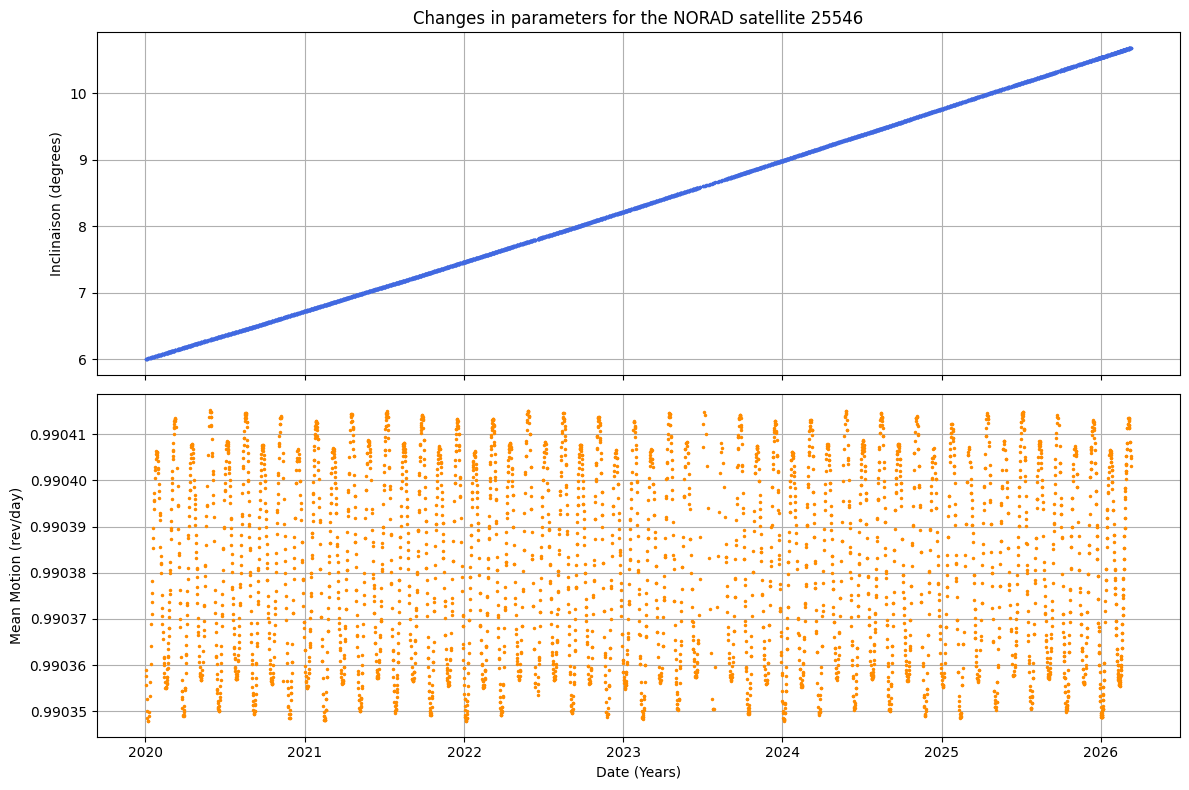

In [7]:
mon_satellite_id = df['norad_id'].unique()[0]
df_sat = df[df['norad_id'] == mon_satellite_id]

# On trie par date pour que le graphique soit propre
df_sat = df_sat.sort_values(by='date')


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Graphique 1 : Inclinaison
ax1.plot(df_sat['date'], df_sat['Inclination'], marker='.', linestyle='', color='royalblue', markersize=3)
ax1.set_ylabel('Inclinaison (degrees)')
ax1.set_title(f'Changes in parameters for the NORAD satellite {mon_satellite_id}')
ax1.grid(True)

# Graphique 2 : mean motion
ax2.plot(df_sat['date'], df_sat['Mean_Motion'], marker='.', linestyle='', color='darkorange', markersize=3)
ax2.set_ylabel('Mean Motion (rev/day)')
ax2.set_xlabel('Date (Years)')
ax2.grid(True)

plt.tight_layout()
plt.show()

### 1. Interpretation: Long-term Drifting Satellite in Graveyard Orbit (NORAD 25546)

The visual analysis of this first satellite reveals the classic behavior of a retired object that has been permanently decommissioned:

1. **Inclination (Uncontrolled Drift):** At the beginning of our dataset in 2020, the inclination is already at 6°, and it continues to grow linearly to over 10° by 2026. Since natural inclination drift is roughly 0.8° per year, we can deduce that North-South station-keeping was abandoned many years prior to 2020.

2. **Mean Motion (Graveyard Orbit):** The mean motion oscillates between 0.9903 and 0.9904 rev/day. In orbital mechanics, we must not round this to 1. A perfectly synchronous GEO satellite has a mean motion of 1.0027 rev/day. A value of 0.990 means the satellite is orbiting slightly *slower* than the Earth's rotation. According to Kepler's third law, a slower orbital period indicates a higher altitude. 

**Conclusion:** This satellite was deliberately pushed into a "Graveyard Orbit" (several hundred kilometers above the active GEO ring) at its end of life. It now drifts safely eastward relative to the ground, unmaintained, with its orbital parameters solely governed by natural Earth and luni-solar gravitational perturbations.

### Search for a satellite maintained in position for the example

To illustrate nominal behavior in GEO, we need to isolate a satellite that is actively maintained in position. 
An active GEO satellite has a controlled inclination. We therefore need to filter the dataset to find satellites with an inclination close to 0.

Active satellite found : NORAD 33436


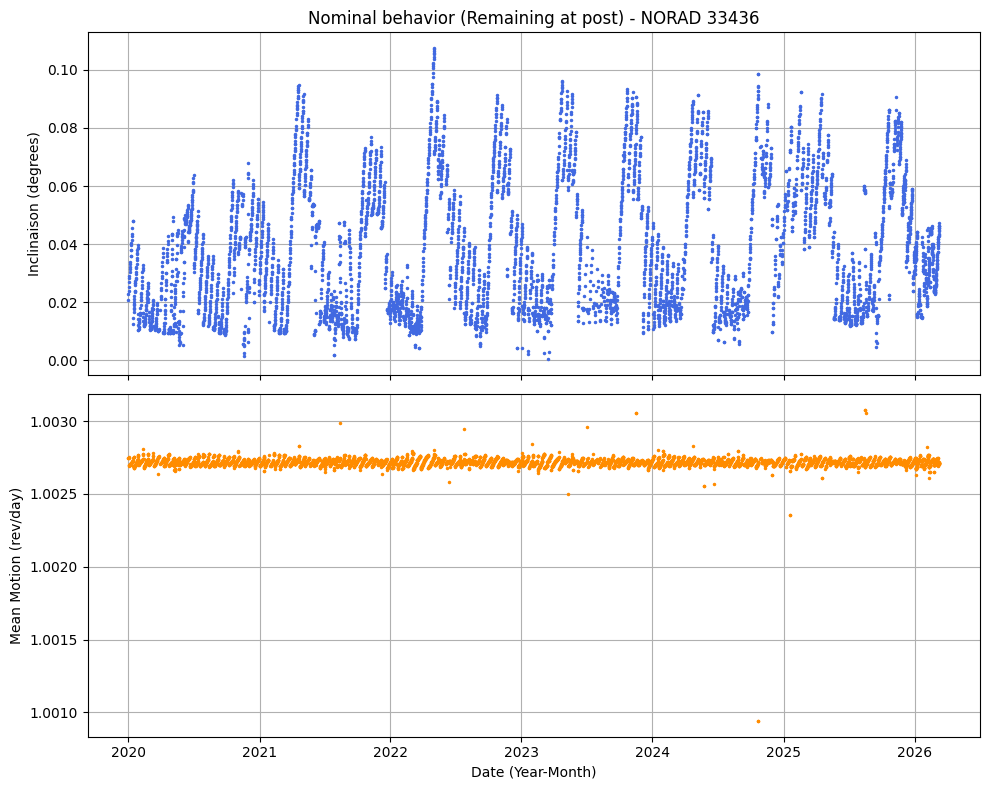

In [17]:

inclinaisons_max = df.groupby('norad_id')['Inclination'].max() # here we group by satellite and take the maximum inclination of each satellite.

# we filter to keep those below 0.10°
active_sats = inclinaisons_max[inclinaisons_max < 0.11].index

if len(active_sats) > 0:
    # we take the first one on this list.
    sat_actif_id = active_sats[0]
    print(f"Active satellite found : NORAD {sat_actif_id}")
    
    # we isolate the data and sort it by date.
    df_actif = df[df['norad_id'] == sat_actif_id].sort_values(by='date')
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Inclinaison Chart
    ax1.plot(df_actif['date'], df_actif['Inclination'], marker='.', linestyle='', color='royalblue', markersize=3)
    ax1.set_ylabel('Inclinaison (degrees)')
    ax1.set_title(f'Nominal behavior (Remaining at post) - NORAD {sat_actif_id}')
    ax1.grid(True)
    
    # Average Movement Chart
    ax2.plot(df_actif['date'], df_actif['Mean_Motion'], marker='.', linestyle='', color='darkorange', markersize=3)
    ax2.set_ylabel('Mean Motion (rev/day)')
    ax2.set_xlabel('Date (Year-Month)')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

else:
    print("No satellite perfectly maintained below 0.15° was found in this sample..")

### 2. Interpretation: Active Station-Keeping (NORAD 33436)

The visual analysis of this second satellite demonstrates the textbook behavior of a fully operational and actively controlled geostationary spacecraft:

1. **Inclination (North-South Control):** The inclination is strictly bounded within a very tight control box (between 0.00° and 0.10°). To counteract the natural gravitational pull of the Sun and Moon that constantly tries to increase this angle, the operator must regularly perform North-South station-keeping maneuvers (thruster burns), keeping the satellite perfectly aligned with the equatorial plane.

2. **Mean Motion (East-West Control):** The mean motion is tightly maintained around the ideal geosynchronous value of 1.0027 revolutions per day. The small variations around this specific value correspond to East-West corrections, counteracting the Earth's asymmetrical gravity and keeping the satellite fixed in its assigned orbital slot.

**Conclusion:** NORAD 33436 is a highly active and continuously monitored satellite. The operator is actively expending propellant to maintain both its latitudinal and longitudinal positions within strict ITU (International Telecommunication Union) operational limits.

### Overall classification of the dataset

To conclude this exploration, we can automate the detection performed earlier to categorize all the satellites in the dataset.

If a satellite's inclination exceeds 1° during the period studied, it can be considered “Drifting” (probably at the end of its life or in a graveyard orbit). If it remains below 1°, we consider it “Active” (maintained in position).

Distribution of satellites in the dataset:
Drifting (End of life)         16
Maintained at post (Active)     9
Name: count, dtype: int64


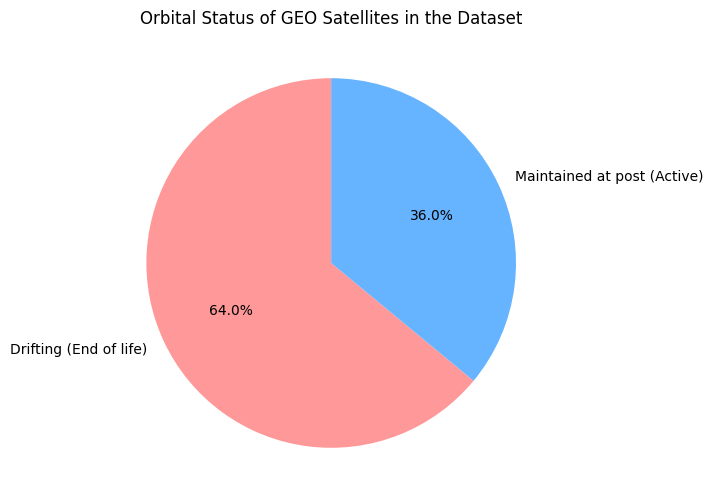

In [19]:
statuts = []

for i in inclinaisons_max:
    if i < 1.0:
        statuts.append("Maintained at post (Active)")
    else:
        statuts.append("Drifting (End of life)")

statuts = pd.Series(statuts) # I convert the list into a pandas Series so that I can use pandas functions

repartition = statuts.value_counts() # I count the number of satellites in each category

print("Distribution of satellites in the dataset:")
print(repartition)

# Pie Chart
plt.figure(figsize=(6, 6))
repartition.plot.pie(
    autopct='%1.1f%%', 
    colors=['#ff9999', '#66b3ff'], 
    startangle=90, 
    title='Orbital Status of GEO Satellites in the Dataset'
)
plt.ylabel('') # Visual cleanup
plt.show()